# 1) Maximum Likelihood Estimation (MLE) and Maximum a Posteriori (MAP)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)

## 1.1) Let $f_\theta(x)$ be a polynomial regression model as in the previous Homework, and let the `poly_regression_small.csv` from Virtuale be the training set. Then, sample 20% of the data in the `poly_regression_large.csv` dataset to use as test set.

In [2]:
# Regression model
def vandermonde(x, K):
    N = x.shape[0]
    Phi = np.ones((K, N))
    for i in range(1, K):
        Phi[i, :] = x**i
    return Phi

def f(x, theta):
    K = theta.shape[0]
    Phi = vandermonde(x, K)
    return Phi.T @ theta

def loss_function_MLE(x, y, theta, _=None):
    K = theta.shape[0]
    Phi = vandermonde(x, K)
    return 0.5 * (np.linalg.norm(Phi.T @ theta - y)**2) / len(y)

def grad_loss_MLE(x, y, theta, _=None):
    K = theta.shape[0]
    Phi = vandermonde(x, K)   
    return Phi @ (Phi.T @ theta - y) / len(y)

def train_test_split (X, Y, N, perc) :
    idx = np.arange(0, N)
    np.random.shuffle(idx)

    idx_train = int(perc*N)

    train_idx = idx[:idx_train]
    test_idx = idx[idx_train:]

    X_train = X[train_idx]
    Y_train = Y[train_idx]

    X_test = X[test_idx]
    Y_test = Y[test_idx]
    return X_train, X_test, Y_train, Y_test

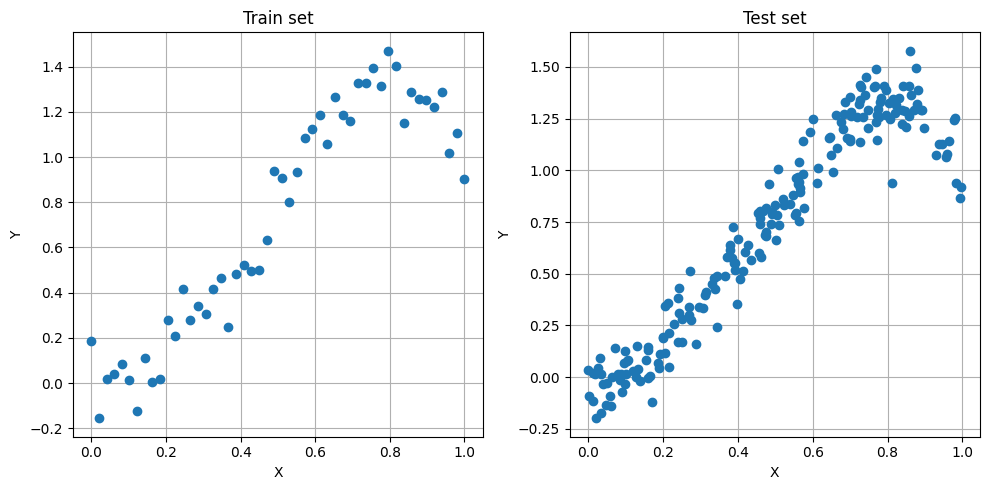

In [3]:
# Dataset split
data_large = pd.read_csv('./poly_regression_large.csv', index_col=0)
X_large = np.array(data_large["x"])
Y_large = np.array(data_large["y"])

data_small = pd.read_csv('./poly_regression_small.csv', index_col=0)
X_small = np.array(data_small["x"])
Y_small = np.array(data_small["y"])

_, X_test, _, Y_test = train_test_split(
    X_large, Y_large, 
    X_large.shape[0], 
    perc=0.8
)
X_train, Y_train = X_small, Y_small

# Visualize dataset
plt.figure(figsize=[10,5])
plt.subplot(121)
plt.plot(X_train,Y_train, 'o')
plt.title("Train set")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()

plt.subplot(122)
plt.plot(X_test,Y_test, 'o')
plt.title("Test set")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()

plt.tight_layout()
plt.show()

## 1.2) For a given value of $K$, write three Python functions computing $\theta_{MLE}$, i.e. the optimal parameters obtained by optimizing the MLE-related loss function with Gaussian assumption on the likelihood $p_\theta(y|x)$, by Gradient Descent, Stochastic Gradient Descent (with a `batch_size`=5), and Normal Equations method with Cholesky Decomposition.

### 1.2.1) Optimization functions

In [4]:
def SGD(loss, grad_loss, D, theta0, alpha=0.05, batch_size=16, n_epochs=200, LAMBDA=None):
    X, y = D  # Unpack the data
    N = X.shape[0]  # Number of samples
    d = theta0.shape[0]  # Number of parameters in theta
    idx = np.arange(N)  # Index array for shuffling

    # History vectors
    theta_history = np.zeros((n_epochs, d))
    loss_history = np.zeros(n_epochs)
    grad_norm_history = np.zeros(n_epochs)

    # Initialize parameters
    theta = theta0
    for epoch in range(n_epochs):
        # Shuffle the data
        np.random.shuffle(idx)
        X_shuffled = X[idx]
        y_shuffled = y[idx]

        grad_loss_vec = []
        for batch_start in range(0, N, batch_size):
            batch_end = min(batch_start + batch_size, N)
            X_batch = X_shuffled[batch_start:batch_end]
            y_batch = y_shuffled[batch_start:batch_end]

            # Compute gradient
            gradient = grad_loss(X_batch, y_batch, theta, LAMBDA)
            grad_loss_vec.append(np.linalg.norm(gradient, 2))

            # Update theta
            theta = theta - alpha * gradient

        # Save history
        theta_history[epoch] = theta
        loss_history[epoch] = loss(X, y, theta, LAMBDA)
        grad_norm_history[epoch] = np.mean(grad_loss_vec)

    return theta_history, loss_history, grad_norm_history


In [5]:
def GD_regression(
       loss_f,                      # Function we want to optimize
       grad_loss,                   # Gradient
       theta0,                      # Starting point
       D,                           # Train dataset
       kmax,                        # Maximum number of iterations
       tolx,                        # The relative tolerance of the algorithm
       tolf,                        # The tolerance for the gradient norm
       alpha=None,                  # Learning rate (optional)
       LAMBDA=None                  # for MAP
    ) -> tuple:

    X_train, Y_train = D
    
    # If alpha is not given we backtrack
    backtracking_enabled = (alpha is None)
    
    # Iniizialize the containers
    thetas, f_val, grads = [], [], []
    
    # Pass actual value to next iteration
    theta_old = theta0
    
    for k in range(kmax):
        # Update containers
        thetas.append(theta_old)
        f_val.append(loss_f(X_train, Y_train, theta_old, LAMBDA))
        grads.append(grad_loss(X_train, Y_train, theta_old, LAMBDA))
        
        # Compute backtracking
        if backtracking_enabled: 
            alpha = backtracking_regression(loss_f, grad_loss, X_train, Y_train, theta_old, LAMBDA)
        
        # Compute the new value
        theta = theta_old - alpha * grad_loss(X_train, Y_train, theta_old, LAMBDA)
        
        # Check the stop condition
        if np.linalg.norm(grad_loss(X_train, Y_train, theta, LAMBDA), 2) <= tolf * np.linalg.norm(grad_loss(X_train, Y_train, theta0, LAMBDA), 2):
            break
        if np.linalg.norm(theta - theta_old, 2) <= tolx:
            break
        
        # Pass actual value to next iteration
        theta_old = theta
    
    return np.array(thetas), k+1, np.array(f_val), np.array(grads)

def backtracking_regression(f, grad_f, X_train, Y_train, theta, LAMBDA=None):
    alpha = 1
    c = 0.8
    tau = 0.25
    
    while f(X_train, Y_train, theta - alpha * grad_f(X_train, Y_train, theta, LAMBDA), LAMBDA) > f(X_train, Y_train, theta, LAMBDA) - c * alpha * np.linalg.norm(grad_f(X_train, Y_train, theta, LAMBDA), 2) ** 2:
        alpha = tau * alpha
        
        if alpha < 1e-3:
            break
    return alpha


In [6]:
def NE_cholesky(K, X, Y, LAMBDA=None):
    if LAMBDA is None:
        # MLE
        PhiX = vandermonde(X, K)
        A = PhiX @ PhiX.T
        b = PhiX @ Y
        theta_final_NE = cholesky(A, b)
    else :
        # MAP
        PhiX = vandermonde(X, K)
        I = np.eye(PhiX.shape[0])  
        A = PhiX @ PhiX.T + LAMBDA * I  
        b = PhiX @ Y  
        theta_final_NE = cholesky(A, b)
        
    return theta_final_NE

def cholesky(A, b):
    L = np.linalg.cholesky(A)
    z = np.linalg.solve(L, b)
    return np.linalg.solve(L.T, z)

### 1.2.2) Experiment

**NOTE**: only the backtracking model was used since from the homework3 it was noticed that it was the best model with each dataset.

In [7]:
from numpy.linalg import LinAlgError

def err(X,Y, model_theta):
    return np.mean(np.square(f(X, model_theta) - Y))

def generalized_experiment(
        K, 
        loss_function, 
        grad_loss, 
        X_train,Y_train,
        X_test,Y_test,
        LAMBDA = None 
    ):
    
    # Starting point (the same for all)
    # theta0 = np.random.randn(K)
    theta0 = np.zeros(K)
    
    # SGD
    theta_history, _, _ = SGD(
        loss_function, grad_loss, 
        (X_train, Y_train), theta0,
        batch_size=5,
        n_epochs=300,
        LAMBDA=LAMBDA
    )
    theta_final_SGD = theta_history[-1]
    
    # GD
    theta_history, _, _, _ = GD_regression(
        loss_function, grad_loss, 
        theta0, (X_train, Y_train),
        kmax=300,
        tolx=1e-5,
        tolf=1e-5,
        LAMBDA=LAMBDA
    )
    theta_final_GD = theta_history[-1]
    
    # NE
    # Use try/except since for big K the condition error becomes too high 
    # and the matrix is not recognised as positive definite
    try:
        theta_final_NE = NE_cholesky(K, X_train, Y_train, LAMBDA=LAMBDA)
        normal_eq=True
    except LinAlgError: 
        normal_eq=False
        
    # Error
    errors_train = {}
    errors_test = {}
    models = {
        "SGD" : theta_final_SGD, 
        "GD" : theta_final_GD, 
    }
    if normal_eq : models["NE"] = theta_final_NE

    for k,v in models.items():
        errors_train[k] = err(X_train, Y_train, v)
        errors_test[k] = err(X_test, Y_test, v)
    
    return models, errors_train, errors_test

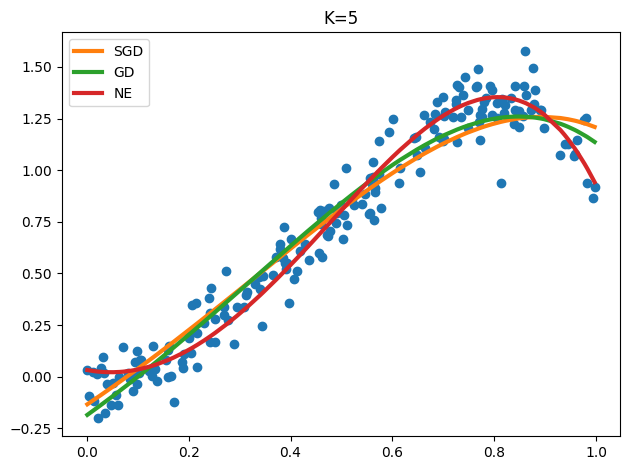

In [8]:
from tqdm import tqdm

K = 5

errors_list_train = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []

}
errors_list_test = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []
}

        
# Run experiment
theta_models, errors_train, errors_test = generalized_experiment(
    K,
    loss_function_MLE, grad_loss_MLE,
    X_train, Y_train, 
    X_test, Y_test
)

# Fill the K-th subplot
plt.title(f"K={K}")
plt.plot(X_test, Y_test, 'o')
idx_sorted = np.argsort(X_test)

for k in errors_list_train:
    errors_list_train[k].append(errors_train[k])
    errors_list_test[k].append(errors_test[k])
    plt.plot(X_test[idx_sorted], f(X_test, theta_models[k])[idx_sorted], label=k, linewidth=3)
        
plt.legend()
plt.tight_layout()
plt.show()

## 1.3) Compare the performance of the three regression model computed above. 

In particular, if $(X_{test}, Y_{test})$ is the test set from the `poly_regression_large.csv` dataset, for each of the model, compute:

**$$ Err = \frac{1}{N_{test}}\sum_{i=1}^{N_{test}}(f_\theta(x^i)-y^i)^2$$**

where $N_{test}$ is the number of elements in the test set, $(x^i, y^i)$ are the input and output elements in the test set. Comment the performance of the three models.

In [9]:
for k,v in errors_list_test.items() : print(f"Model {k}: \t err = {v[0]}")

Model SGD: 	 err = 0.015156403680565192
Model GD: 	 err = 0.01344991502287215
Model NE: 	 err = 0.010670126729875985


## 1.4) For different values of $K$, plot the training datapoints and the test datapoints with different colors and visualize (as a continuous line) the three learned regression model $f_\theta(x)$. Comment the results.

K progress: 25it [00:08,  3.09it/s]


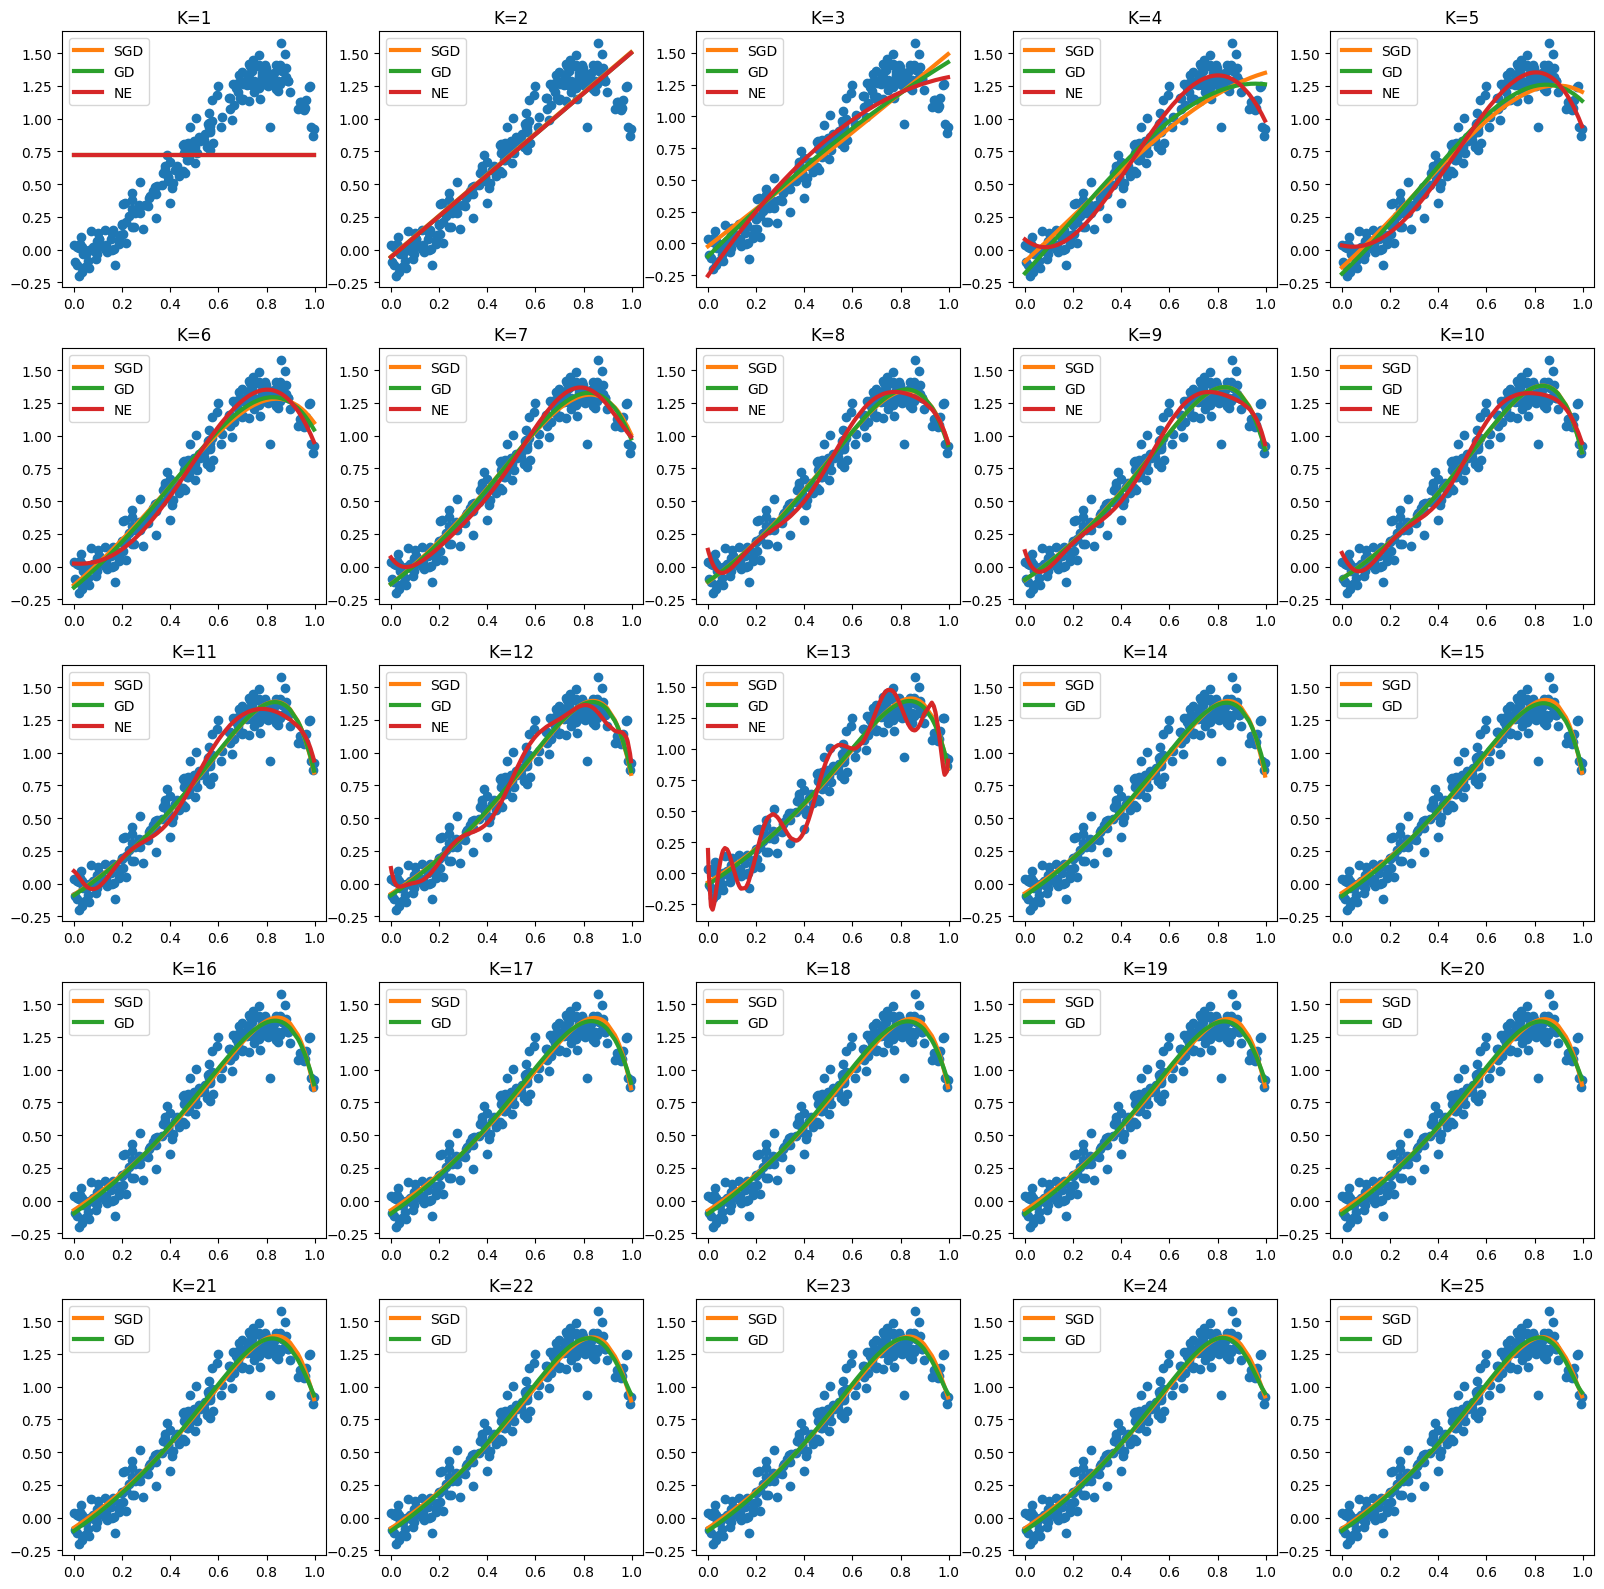

In [10]:
from tqdm import tqdm

Ks = [*range(1, 26)]

errors_list_train = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []

}
errors_list_test = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []
}

# Obtain a square grid of subplots
n = len(Ks)
cols = int(np.ceil(np.sqrt(n)))  
rows = int(np.ceil(n / cols))    
fig, axes = plt.subplots(rows, cols, figsize=(n//1.5,n//1.5))
axes = axes.flatten()

for i, K in tqdm(enumerate(Ks), desc="K progress"):
    
    # Run experiment
    theta_models, errors_train, errors_test = generalized_experiment(
        K,
        loss_function_MLE, grad_loss_MLE,
        X_train, Y_train, 
        X_test, Y_test,
        # LAMBDA=0.001  # will make the K>13 matrices invertible for cholesky
    )
    
    # Fill the K-th subplot
    axes[i].set_title(f"K={K}")
    axes[i].plot(X_test, Y_test, 'o')
    idx_sorted = np.argsort(X_test)
    try:
        for k in errors_list_train:
            errors_list_train[k].append(errors_train[k])
            errors_list_test[k].append(errors_test[k])
            axes[i].plot(X_test[idx_sorted], f(X_test, theta_models[k])[idx_sorted], label=k, linewidth=3)
    except KeyError: pass
    axes[i].legend()

# Plot the subplots
plt.tight_layout()
plt.show()

- We can notice that as the $K$ grows we can see the polynomial degree growing
- GD and SGD are more robust with respect to the $K$ and can performed with each of them
- NE suffers from overfitting and has numerical problem as the $K$ grows (because the ill-conditioning of Vandermonde matrix) and can't be plotted from $K > 13$ because cholesky decomposition requires a positive definite matrix.
- We can see that the overfit of NE starts around $K=6$

## 1.5) For increasing values of $K$, compute the training and test error as discussed above. Plot the two errors with respect to $K$. Comment the results.

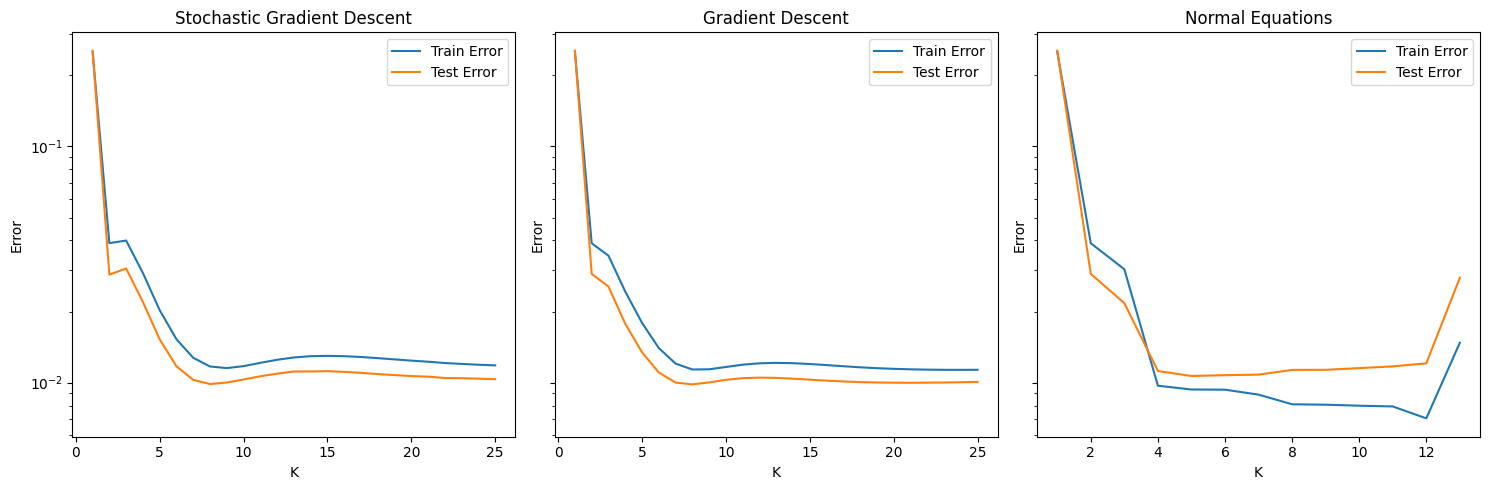

In [11]:
models = errors_list_train.keys()
model_name = {
    "SGD" : "Stochastic Gradient Descent",
    "GD" : "Gradient Descent",
    "NE" : "Normal Equations"
}

fig, axs = plt.subplots(1, len(models), figsize=(15, 5), sharey=True)

for ax, model in zip(axs, models):
    ax.plot(Ks[:len(errors_list_train[model])], errors_list_train[model], label="Train Error")
    ax.plot(Ks[:len(errors_list_test[model])], errors_list_test[model], label="Test Error")

    ax.set_title(f"{model_name[model]}")
    ax.set_xlabel("K")
    ax.set_yscale("log")
    ax.set_ylabel("Error")
    ax.legend()

plt.tight_layout()
plt.show()

- We can notice that the Normal equations are overfitting from $K=4$ and on, since the model becomes more and more sensitive to outliers.
- GD and SGD have slightly higher erorrs but they are more balanced as train and test error are more similar.

## 1.6) Repeat the same experiments by considering the MAP formulation with Gaussian assumption on the prior term $p(\theta)$. Set $K=8$ and test different values of $\lambda > 0$ in the experiments. 
Comment the results, comparing:
- the three optimization method used to obtain $\theta_{MAP}$
- the different values of $\lambda > 0$
- the results obtained by $\theta_{MLE}$ vs $\theta_{MAP}$

In [12]:
def loss_function_MAP(x, y, theta, LAMBDA):
    return loss_function_MLE(x, y, theta) + LAMBDA/2*(np.linalg.norm(theta)**2)

def grad_loss_MAP(x, y, theta, LAMBDA):
    return grad_loss_MLE(x, y, theta) + LAMBDA*theta

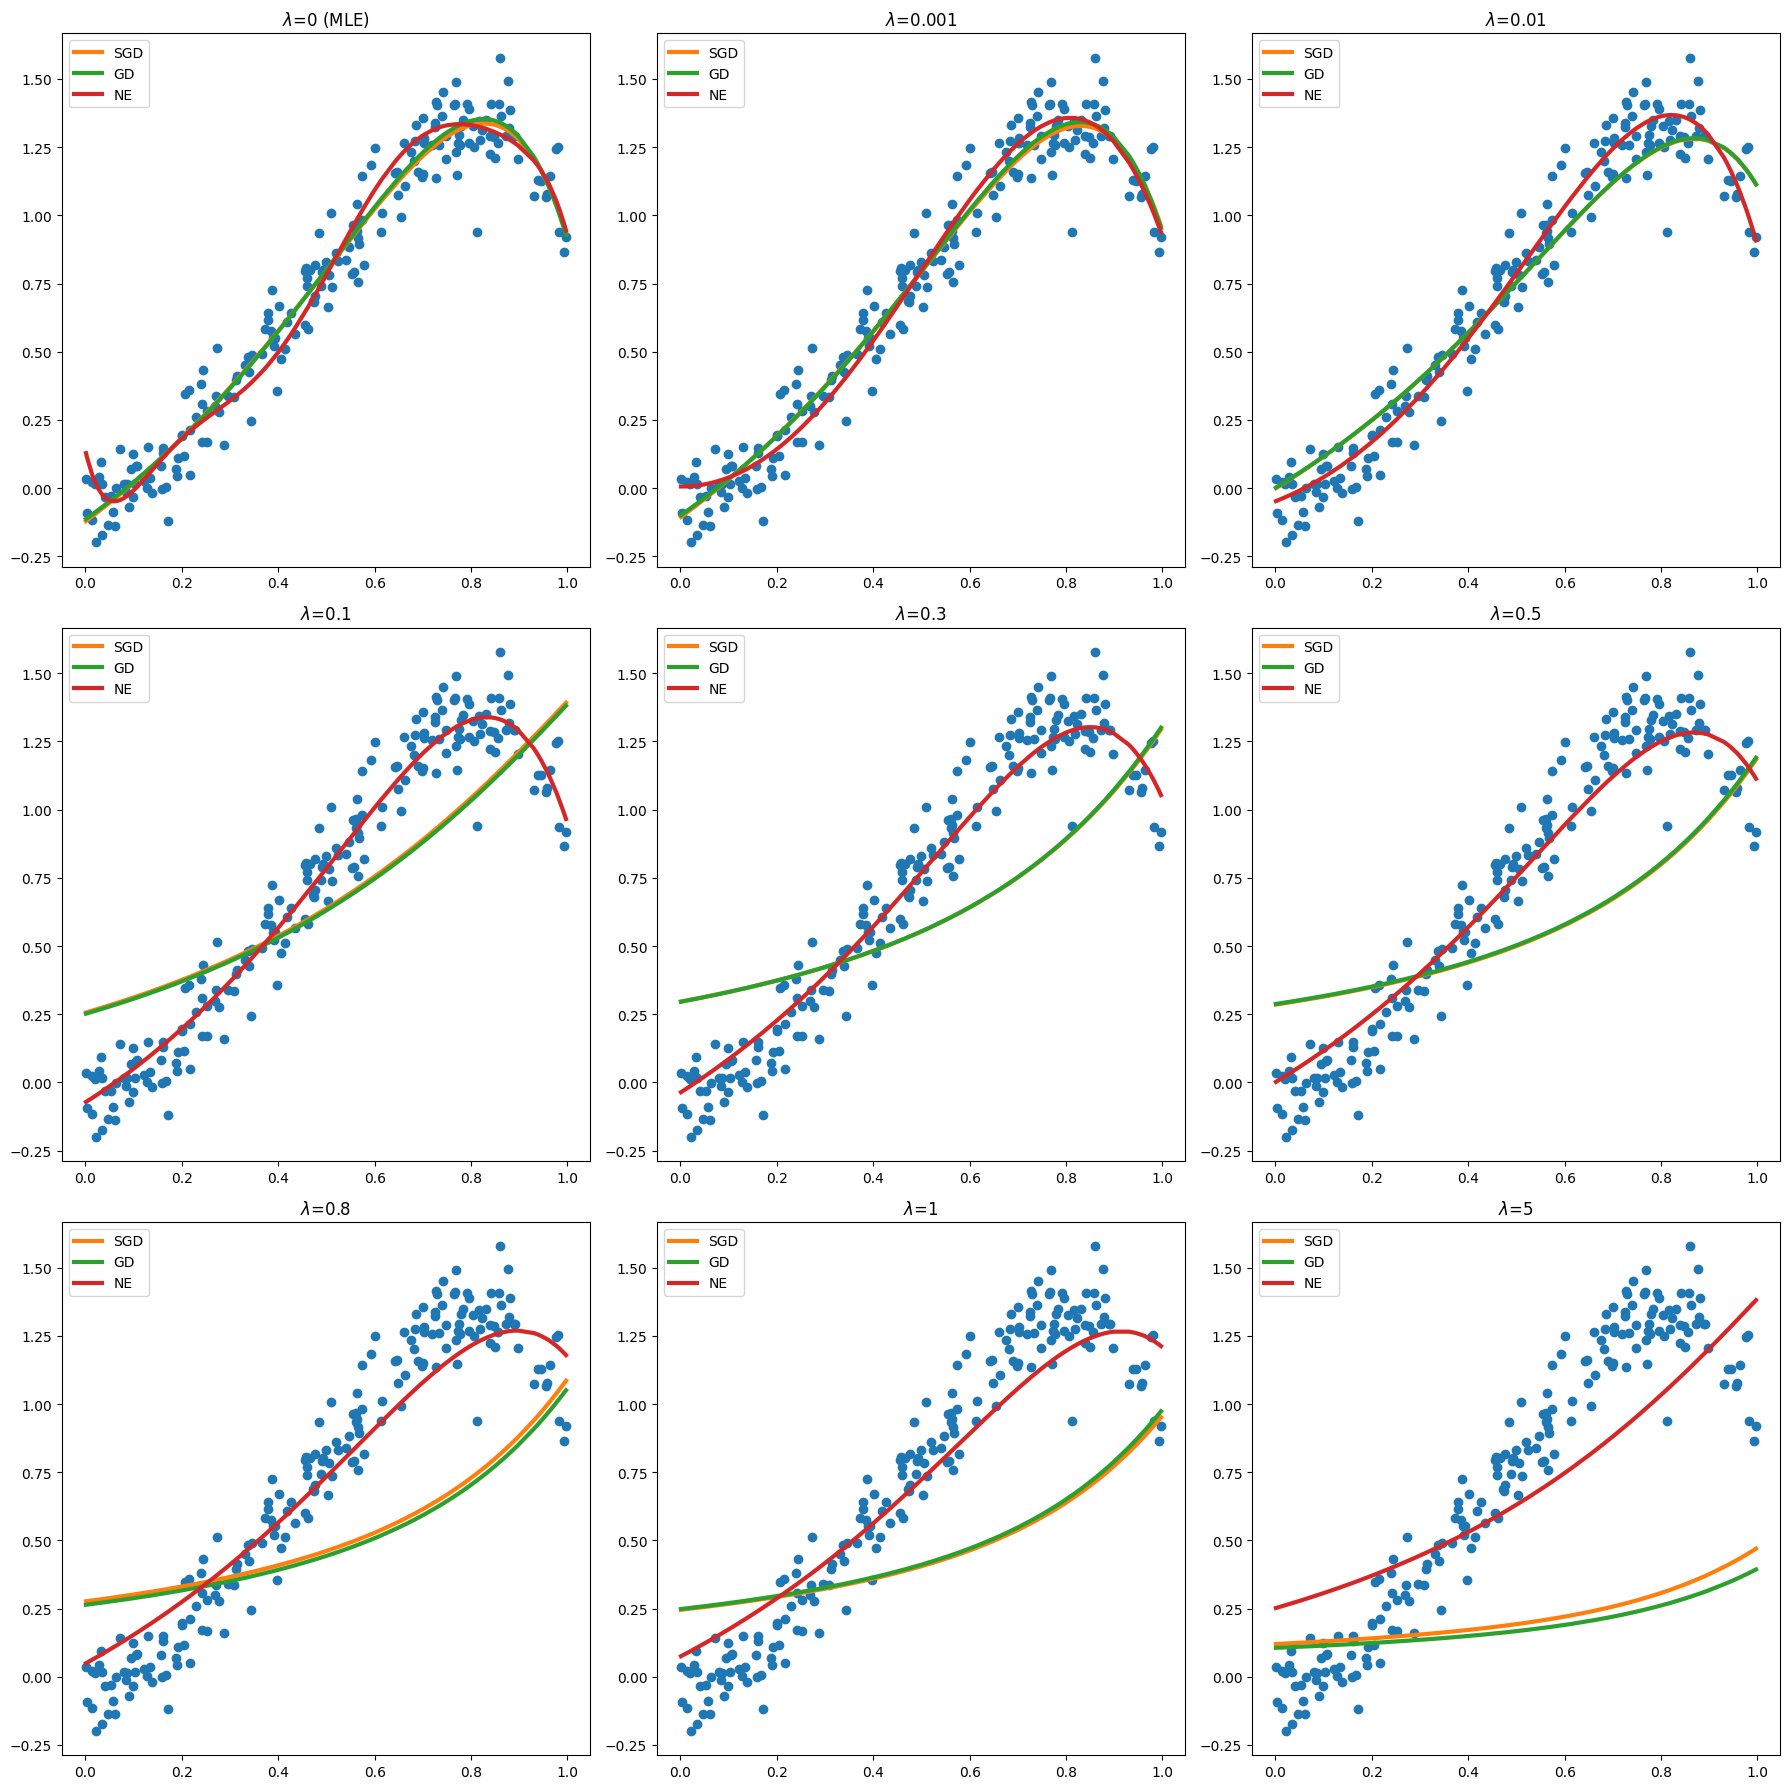

In [13]:
# Run experiment
K = 8

# Construct LAMBDAS
LAMBDAS = [0, 0.001, 0.01, 0.1, 0.3, 0.5, 0.8, 1, 5]


##### MLE ############################################################
# lamnda = 0 in the MAP

##### MAP ############################################################
errors_list_train = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []
}
errors_list_test = {
    "SGD" : [], 
    "GD" : [], 
    "NE" : []
}

# Obtain a square grid of subplots
n = len(LAMBDAS)
cols = int(np.ceil(np.sqrt(n)))  
rows = int(np.ceil(n / cols))    
fig, axes = plt.subplots(rows, cols, figsize=(n*2,n*2))
axes = axes.flatten()

for i, LAMBDA in enumerate(LAMBDAS):
    
    LAMBDA = round(LAMBDA, 4)
    
    # Run experiment
    theta_models_MAP, errors_train_MAP, errors_test_MAP = generalized_experiment(
        K,
        loss_function_MAP, grad_loss_MAP,
        X_train, Y_train, 
        X_test, Y_test,
        LAMBDA=LAMBDA
    )
    
    # Fill the K-th subplot
    axes[i].set_title(fr"$\lambda$={LAMBDA}" if LAMBDA!=0 else fr"$\lambda$={LAMBDA} (MLE)")
    axes[i].plot(X_test, Y_test, 'o')
    idx_sorted = np.argsort(X_test)
    try:
        for k in errors_list_train:
            errors_list_train[k].append(errors_train_MAP[k])
            errors_list_test[k].append(errors_test_MAP[k])
            axes[i].plot(X_test[idx_sorted], f(X_test, theta_models_MAP[k])[idx_sorted], label=k, linewidth=3)
    except KeyError: pass
    axes[i].legend()
    
plt.tight_layout()
plt.show()

- We can notice that in the MLE the regressors were a little instable and as we add even a low lambda ($\lambda = 0.001$) then all the regressors regularize.
Because the higher the $\lambda$ and the more the objective function modifies and we care less of the gradient of the error of the prediction and so we learn less accurately and so we become more insensitive to outliers in order to perform regularization.
- The more we increase $\lambda$ and the more we will change the actual function to minimize, changing the minima to find and so as this modification increase also the solution changes and we see that the 3 methods reacts differently to this:
    - **NE**: this is a single calculation of the exact solution so it only shifts as the modification makes it shift
    - **GD & SGD**: those iterative algorithms compute several calculations and so the modification occurs more and more and this increase error, making them converge in a different minima wrt NE

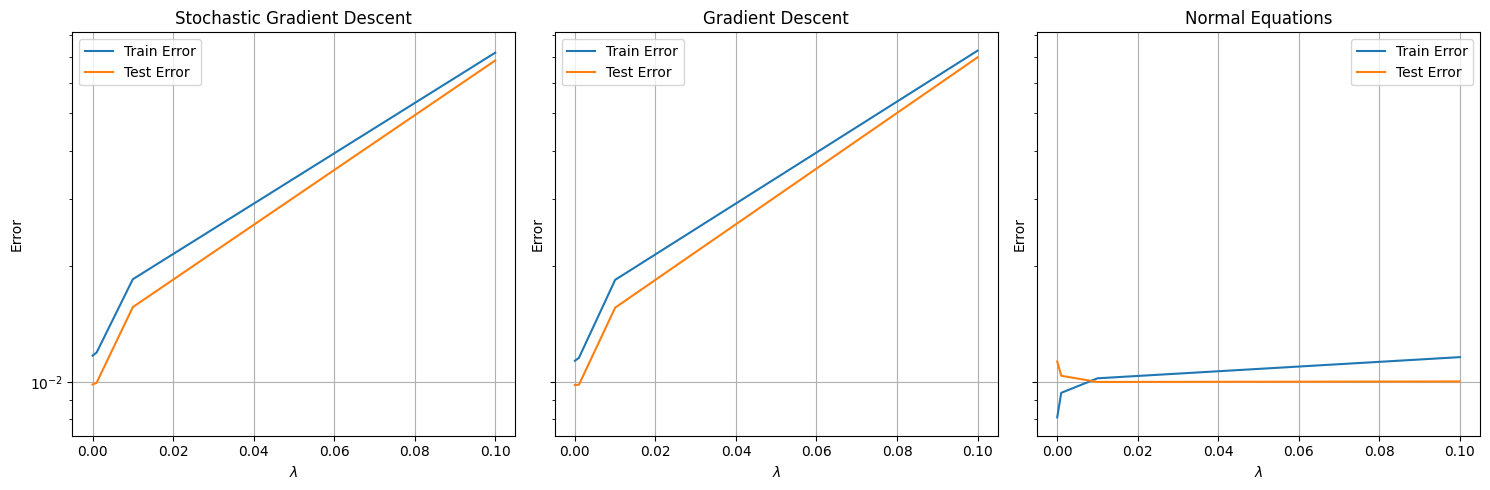

In [14]:
models = errors_list_train.keys()
model_name = {
    "SGD" : "Stochastic Gradient Descent",
    "GD" : "Gradient Descent",
    "NE" : "Normal Equations"
}

fig, axs = plt.subplots(1, len(models), figsize=(15, 5), sharey=True)

for ax, model in zip(axs, models):
    
    # I select only the first points to better see the pattern
    ax.plot(LAMBDAS[:4], errors_list_train[model][:4], label="Train Error")
    ax.plot(LAMBDAS[:4], errors_list_test[model][:4], label="Test Error")

    ax.set_title(f"{model_name[model]}")
    ax.set_xlabel(r"$\lambda$")
    ax.set_yscale("log")
    # ax.set_xscale("log")
    ax.set_ylabel("Error")
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

As we could notice from before, the higher the $\lambda$ and the more the insensitivity of the model becomes a problem and the model increases errors both in test and train. Notice that is not a problem of overfitting, since train and test don't differ that much.

In [15]:
# Observation

NE_cholesky(K=15, X=X_test, Y=Y_test, LAMBDA=0.001)

array([-0.0757115 ,  0.79082063,  2.22687536, -0.16608859, -0.49475775,
       -0.3987045 , -0.36726376, -0.36076179, -0.30387154, -0.18610553,
       -0.04154111,  0.08269597,  0.14528031,  0.11785868, -0.01450773])

Moreover, we could observe that now we can compute the vandermonde matrices with $K > 13$ since with the $\lambda$ applied we add a small quantuty on the diagonal making the columns no more dependent and so the matrix become full-rank and positive definite.